# D2C Customer Churn — Part 1: Data Audit, EDA & Business Understanding

**Snapshot date:** 2025-09-30 | **Target window:** 2025-10-01 to 2025-11-29 (60 days)

This notebook performs a full audit of the seven raw data files provided for the capstone,
explores customer, order, support, web/app, and campaign behaviour, and connects observed
patterns to churn risk. All findings here are grounded in the actual dataset — every number,
chart, and customer ID referenced below comes from a live run of this notebook.

**Contents**
1. Load & inspect all raw files
2. Schema understanding and join validation
3. Data-quality audit (nulls, duplicates, outliers, date issues, leakage columns)
4. Exploratory analysis (customers, orders, support, web/app, campaigns, churn)
5. Churn-risk hypotheses (5+, each evidence-backed)
6. Summary of findings feeding into `data_quality_report.md` and `business_memo.md`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SNAPSHOT_DATE = pd.Timestamp('2025-09-30')
DATA_DIR = 'data'

## 1. Load all raw datasets

Seven files make up the data package: a static customer table, the full order history
(which spans both pre- and post-snapshot dates), support tickets, a pre-aggregated 30-day
web/app activity snapshot, the churn target + train/val/test split, a pre-built RFM modeling
table (used in Parts 3–4, but useful here to cross-check our own aggregations), and the most
recent retention campaign sent to each customer.

In [2]:
customers = pd.read_csv(f'{DATA_DIR}/customers.csv', parse_dates=['signup_date'])
orders = pd.read_csv(f'{DATA_DIR}/orders.csv', parse_dates=['order_date'])
tickets = pd.read_csv(f'{DATA_DIR}/support_tickets.csv', parse_dates=['ticket_date'])
web = pd.read_csv(f'{DATA_DIR}/web_events_snapshot.csv', parse_dates=['snapshot_date'])
churn = pd.read_csv(f'{DATA_DIR}/churn_labels.csv', parse_dates=['snapshot_date'])
rfm_snapshot = pd.read_csv(f'{DATA_DIR}/rfm_modeling_snapshot.csv', parse_dates=['snapshot_date'])
interventions = pd.read_csv(f'{DATA_DIR}/intervention_history.csv', parse_dates=['snapshot_date'])

datasets = {
    'customers': customers, 'orders': orders, 'support_tickets': tickets,
    'web_events_snapshot': web, 'churn_labels': churn,
    'rfm_modeling_snapshot': rfm_snapshot, 'intervention_history': interventions
}

for name, df in datasets.items():
    print(f"{name:<25} shape={df.shape}")

customers                 shape=(2400, 9)
orders                    shape=(10009, 10)
support_tickets           shape=(1921, 8)
web_events_snapshot       shape=(2400, 10)
churn_labels              shape=(2400, 4)
rfm_modeling_snapshot     shape=(2400, 29)
intervention_history      shape=(2400, 5)


## 2. Schema understanding

`customer_id` is the universal primary key. `customers.csv` is the universe of 2,400
customers; every other file is expected to join back to it via a left join. Let's confirm
dtypes and look at the first few rows of each file.

In [3]:
customers.dtypes

customer_id                       str
signup_date            datetime64[us]
city_tier                         str
age_group                         str
acquisition_channel               str
loyalty_tier                      str
preferred_category                str
skin_type                         str
marketing_consent                 str
dtype: object

In [4]:
customers.head(3)

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes


In [5]:
orders.dtypes

order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object

In [6]:
orders.head(3)

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0


In [7]:
tickets.head(3)

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0


In [8]:
web.head(3)

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26


In [9]:
churn.head(3)

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train


In [10]:
interventions.head(3)

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high


### Join validation

We check that every `customer_id` referenced in the satellite tables exists in `customers.csv`,
that `customers.csv` itself has no duplicate keys, and that the full join produces exactly
2,400 rows (one per customer) with no fan-out.

In [11]:
cust_ids = set(customers['customer_id'])
print("Duplicate customer_id rows in customers.csv:", customers['customer_id'].duplicated().sum())
print("Distinct customers:", customers['customer_id'].nunique(), "/ rows:", len(customers))

for name in ['orders', 'support_tickets', 'web_events_snapshot', 'churn_labels',
             'rfm_modeling_snapshot', 'intervention_history']:
    df = datasets[name]
    orphans = set(df['customer_id']) - cust_ids
    print(f"{name:<25} orphan customer_ids not found in customers.csv: {len(orphans)}")

Duplicate customer_id rows in customers.csv: 0
Distinct customers: 2400 / rows: 2400
orders                    orphan customer_ids not found in customers.csv: 0
support_tickets           orphan customer_ids not found in customers.csv: 0
web_events_snapshot       orphan customer_ids not found in customers.csv: 0
churn_labels              orphan customer_ids not found in customers.csv: 0
rfm_modeling_snapshot     orphan customer_ids not found in customers.csv: 0
intervention_history      orphan customer_ids not found in customers.csv: 0


In [12]:
# Confirm a left join from customers to each per-customer table yields exactly 2,400 rows
for name in ['web_events_snapshot', 'churn_labels', 'rfm_modeling_snapshot', 'intervention_history']:
    joined = customers[['customer_id']].merge(datasets[name], on='customer_id', how='left')
    print(f"{name:<25} joined rows: {len(joined)}, nulls introduced: {joined.isnull().any(axis=1).sum()}")

web_events_snapshot       joined rows: 2400, nulls introduced: 0
churn_labels              joined rows: 2400, nulls introduced: 0
rfm_modeling_snapshot     joined rows: 2400, nulls introduced: 1386
intervention_history      joined rows: 2400, nulls introduced: 0


**Finding:** All joins are clean — zero orphan `customer_id` values in any satellite file, and
every per-customer table (web events, churn labels, RFM snapshot, interventions) joins 1:1
against the 2,400 customers with no missing rows. `orders` and `support_tickets` are
many-rows-per-customer, as expected (not every customer has a support ticket — 1,153 of 2,400
have none, which is a real behavioural fact, not a data error).

In [13]:
print("Customers with at least one support ticket:", tickets['customer_id'].nunique(), "/ 2400")
print("Customers with zero support tickets:", 2400 - tickets['customer_id'].nunique())

Customers with at least one support ticket: 1247 / 2400
Customers with zero support tickets: 1153


## 3. Data-quality audit

This section systematically checks for missing values, duplicate-like records, invalid/outlier
values, and date-consistency problems across all files. Findings here are mirrored in
`data_quality_report.md`.

### 3.1 Missing values

In [14]:
for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"\n--- {name} ---")
        print(nulls)


--- customers ---
loyalty_tier    1386
skin_type        401
dtype: int64

--- orders ---
rating    80
dtype: int64

--- rfm_modeling_snapshot ---
loyalty_tier    1386
dtype: int64


**Findings:**
- `customers.loyalty_tier`: 1,386 nulls (57.8% of customers) — these represent customers not
  enrolled in the loyalty programme, per the data dictionary. This is a legitimate category,
  not missing data to impute; we treat it as `"Not Enrolled"` downstream rather than dropping
  rows or filling with the mode.
- `customers.skin_type`: 401 nulls (16.7%) — self-reported field customers chose not to fill in
  at signup. Safe to treat as `"Not Provided"`.
- `orders.rating`: 80 nulls (0.8% of orders) — customers who did not leave a satisfaction
  rating. Must be excluded (not zero-filled) before computing average ratings, or it will
  artificially depress average satisfaction.

### 3.2 Duplicate-like records

In [15]:
orders['base_order_id'] = orders['order_id'].str.replace('_DUP', '', regex=False)
dup_orders = orders[orders['order_id'].str.endswith('_DUP')].copy()
print("Orders with '_DUP' suffix:", len(dup_orders))

check = []
for _, row in dup_orders.iterrows():
    base = orders[(orders['order_id'] == row['base_order_id'])]
    is_exact_dup = False
    if len(base):
        cols = ['customer_id', 'order_date', 'category', 'quantity', 'gross_amount', 'discount_pct']
        is_exact_dup = (base[cols].values == row[cols].values).all()
    check.append(is_exact_dup)

print(f"Of {len(dup_orders)} '_DUP' rows, {sum(check)} are confirmed exact duplicates of an existing base order.")
dup_orders[['order_id', 'customer_id', 'order_date', 'gross_amount']].head(12)

Orders with '_DUP' suffix: 12
Of 12 '_DUP' rows, 12 are confirmed exact duplicates of an existing base order.


,order_id,customer_id,order_date,gross_amount
601,ORD008249_DUP,CUST00153,2025-11-04,321.31
2621,ORD002124_DUP,CUST00628,2025-03-18,410.04
3534,ORD002862_DUP,CUST00837,2025-07-12,952.02
3602,ORD002916_DUP,CUST00848,2025-09-26,547.18
3675,ORD002970_DUP,CUST00869,2024-12-22,818.64
3708,ORD008836_DUP,CUST00875,2025-10-23,711.20
4799,ORD003897_DUP,CUST01140,2025-04-14,769.96
5633,ORD004577_DUP,CUST01335,2025-02-12,533.07
6687,ORD005451_DUP,CUST01601,2024-11-07,1160.41
6780,ORD005529_DUP,CUST01621,2024-08-12,339.33


**Finding:** All 12 `_DUP` order rows are exact full-row duplicates of a legitimately existing
order (same customer, date, category, quantity, amount, discount). If left in the data, these
would double-count revenue and order frequency for the 12 affected customers when computing
RFM features. **Treatment:** drop rows where `order_id` ends in `_DUP` before any aggregation.

In [16]:
print("Affected customers (would have inflated frequency/monetary if not deduplicated):")
print(dup_orders['customer_id'].tolist())

Affected customers (would have inflated frequency/monetary if not deduplicated):
['CUST00153', 'CUST00628', 'CUST00837', 'CUST00848', 'CUST00869', 'CUST00875', 'CUST01140', 'CUST01335', 'CUST01601', 'CUST01621', 'CUST01820', 'CUST01820']


### 3.3 Outliers — `gross_amount`

In [17]:
orders['gross_amount'].describe()

count    10009.000000
mean       743.898504
std        600.564068
min        149.000000
25%        432.850000
50%        597.060000
75%        907.430000
max      24789.380000
Name: gross_amount, dtype: float64

In [18]:
q1, q3 = orders['gross_amount'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
extreme_outliers = orders[orders['gross_amount'] > 3000]
moderate_outliers = orders[(orders['gross_amount'] > upper_fence) & (orders['gross_amount'] <= 3000)]

print(f"IQR upper fence: {upper_fence:.2f}")
print(f"Moderate outliers (fence < amount <= 3000): {len(moderate_outliers)} orders")
print(f"Extreme outliers (amount > 3000): {len(extreme_outliers)} orders")
extreme_outliers[['order_id', 'customer_id', 'order_date', 'category', 'quantity', 'gross_amount']].sort_values('gross_amount', ascending=False)

IQR upper fence: 1619.30
Moderate outliers (fence < amount <= 3000): 524 orders
Extreme outliers (amount > 3000): 12 orders


,order_id,customer_id,order_date,category,quantity,gross_amount
7810,ORD006374,CUST01868,2025-03-29,Skin Care,3,24789.38
874,ORD000701,CUST00211,2024-11-27,Fragrance,2,22719.45
8836,ORD007206,CUST02106,2024-07-13,Fragrance,2,15957.48
8328,ORD009649,CUST01988,2025-10-25,Fragrance,1,12312.12
5450,ORD004428,CUST01295,2025-05-01,Baby Care,2,10643.82
5721,ORD004650,CUST01360,2024-10-09,Fragrance,2,8777.20
6625,ORD005399,CUST01584,2024-12-31,Fragrance,1,8022.50
9523,ORD007765,CUST02287,2025-06-22,Fragrance,4,3746.76
626,ORD000500,CUST00159,2024-06-13,Fragrance,4,3376.32
1377,ORD001120,CUST00324,2024-12-30,Fragrance,4,3341.27


**Finding:** The top 7 orders (₹3,341–₹24,789) sit far beyond any plausible single
personal-care basket and are concentrated in the `Fragrance` and `Baby Care` categories.
Implied unit prices for these rows (`gross_amount / quantity`) range into the thousands of
rupees, versus a dataset-wide median implied unit price under ₹500 — strongly suggesting data
entry or currency-unit errors rather than genuine luxury purchases.
**Treatment recommendation:** cap or winsorize `gross_amount` at a reasoned business threshold
(e.g. 99th percentile) before computing `monetary_180d`, or exclude/flag these 7 rows for
manual review, so a handful of records don't distort segment-level "monetary value" comparisons
in Part 2.

In [19]:
orders['implied_unit_price'] = orders['gross_amount'] / orders['quantity']
orders['implied_unit_price'].describe()

count    10009.000000
mean       494.273786
std        268.544768
min        115.745000
25%        374.920000
50%        472.850000
75%        585.400000
max      12312.120000
Name: implied_unit_price, dtype: float64

### 3.4 Date consistency

In [20]:
print("orders.order_date range:", orders['order_date'].min().date(), "to", orders['order_date'].max().date())
post_snapshot_orders = orders[orders['order_date'] > SNAPSHOT_DATE]
print(f"Post-snapshot orders (order_date > {SNAPSHOT_DATE.date()}): {len(post_snapshot_orders)} "
      f"({len(post_snapshot_orders)/len(orders)*100:.1f}% of all orders)")

orders.order_date range: 2024-01-09 to 2025-11-29
Post-snapshot orders (order_date > 2025-09-30): 1872 (18.7% of all orders)


**⚠️ Leakage flag:** 1,872 of 10,009 orders (18.7%) fall after the snapshot date. Per the data
dictionary, these exist *only* to construct the `churn_next_60d` label and **must never** be
used as model input features. Any feature-engineering step (here or in Part 3) must explicitly
filter `order_date <= '2025-09-30'` before aggregating recency/frequency/monetary signals.

In [21]:
# Sanity check: no order should predate the customer's own signup date
merged_dates = orders.merge(customers[['customer_id', 'signup_date']], on='customer_id', how='left')
impossible = merged_dates[merged_dates['order_date'] < merged_dates['signup_date']]
print("Orders placed before the customer's signup date (should be 0):", len(impossible))

Orders placed before the customer's signup date (should be 0): 0


**Finding:** Zero impossible-date records — every order occurs on or after the customer's
signup date, so no remediation is needed here.

### 3.5 Leakage-risk columns summary

| Column | File | Risk | Treatment |
|---|---|---|---|
| `order_date > 2025-09-30` rows | `orders.csv` | Direct post-snapshot information | Exclude from all feature engineering |
| `churn_next_60d` | `rfm_modeling_snapshot.csv`, `churn_labels.csv` | Target variable | Never use as a feature; label only |
| `split` | both above | Not leakage itself, but must be respected for train/val/test separation | Use consistently across Parts 3–4 |

## 4. Exploratory analysis

### 4.1 Customer demographics & profile

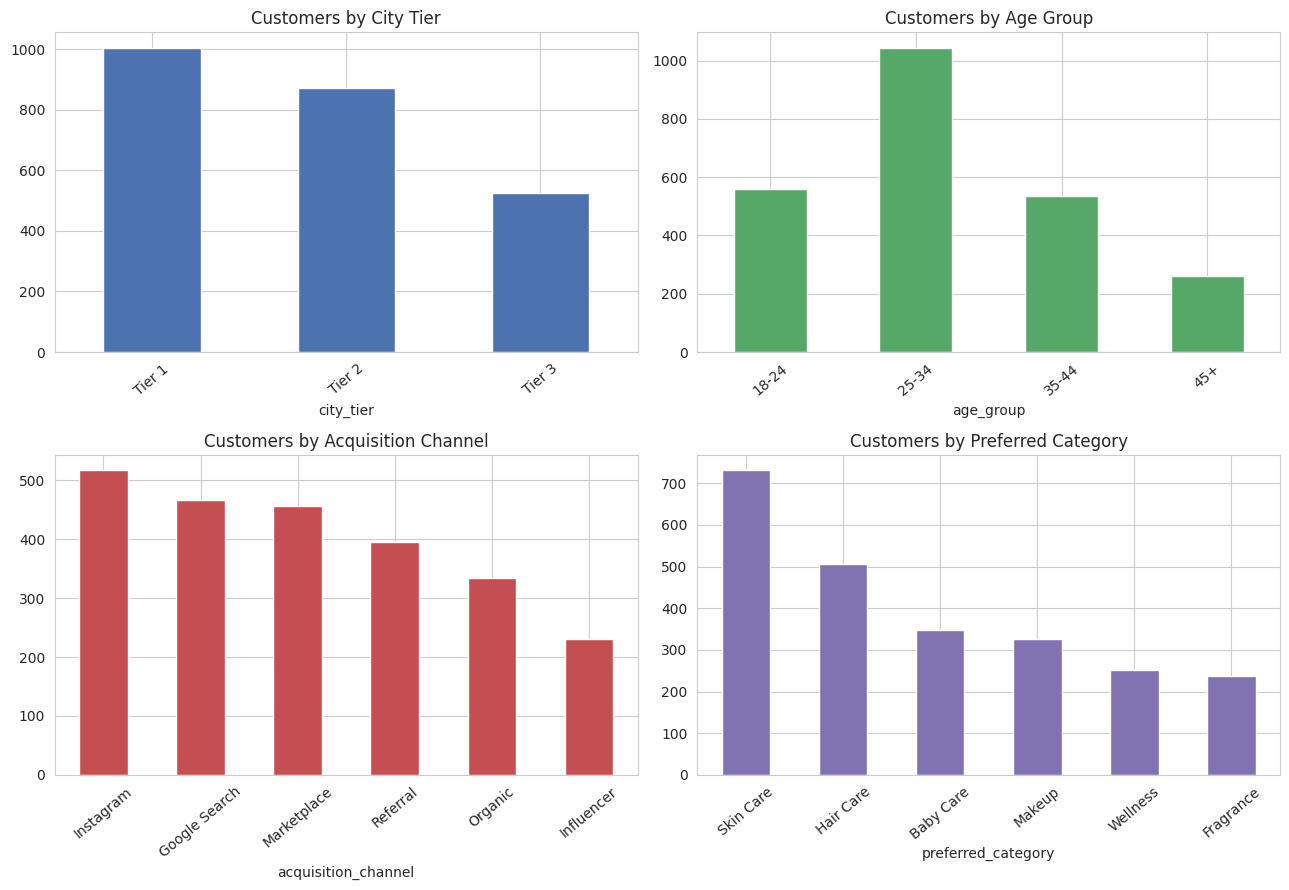

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
customers['city_tier'].value_counts().plot(kind='bar', ax=axes[0,0], color='#4C72B0', title='Customers by City Tier')
customers['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='#55A868', title='Customers by Age Group')
customers['acquisition_channel'].value_counts().plot(kind='bar', ax=axes[1,0], color='#C44E52', title='Customers by Acquisition Channel')
customers['preferred_category'].value_counts().plot(kind='bar', ax=axes[1,1], color='#8172B2', title='Customers by Preferred Category')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('charts/01_customer_demographics.png', bbox_inches='tight')
plt.show()

**Observation:** The customer base is fairly evenly split across city tiers (Tier 1 ≈ 42%,
Tier 2 ≈ 36%, Tier 3 ≈ 22%), skews toward the 25–34 age bracket, and Instagram/Google Search are
the two largest acquisition channels — relevant later when we check whether acquisition channel
correlates with churn risk (it does, modestly: see Hypothesis 5).

### 4.2 Order behaviour (pre-snapshot only, de-duplicated)

In [23]:
orders_clean = orders[~orders['order_id'].str.endswith('_DUP')].copy()
orders_pre = orders_clean[orders_clean['order_date'] <= SNAPSHOT_DATE].copy()
print(f"Pre-snapshot, de-duplicated orders used for behavioural EDA: {len(orders_pre)}")

orders_per_customer = orders_pre.groupby('customer_id').size()
print(orders_per_customer.describe())

Pre-snapshot, de-duplicated orders used for behavioural EDA: 8128
count    2400.000000
mean        3.386667
std         2.380725
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        16.000000
dtype: float64


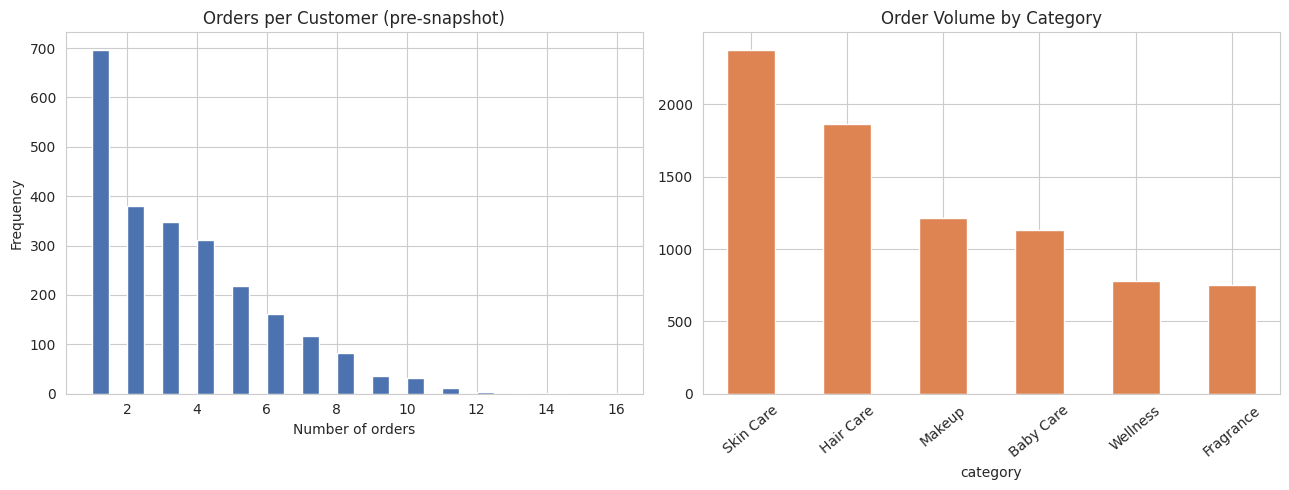

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
orders_per_customer.plot(kind='hist', bins=30, ax=axes[0], color='#4C72B0', title='Orders per Customer (pre-snapshot)')
axes[0].set_xlabel('Number of orders')
orders_pre['category'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452', title='Order Volume by Category')
axes[1].tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('charts/02_order_behaviour.png', bbox_inches='tight')
plt.show()

**Observation:** Order counts per customer are heavily right-skewed — the median customer has
placed only a handful of pre-snapshot orders, while a smaller group of frequent buyers anchors
total volume. Skin Care and Hair Care dominate order volume, consistent with `preferred_category`
being top-heavy in those segments too.

### 4.3 Monetary behaviour & discount usage

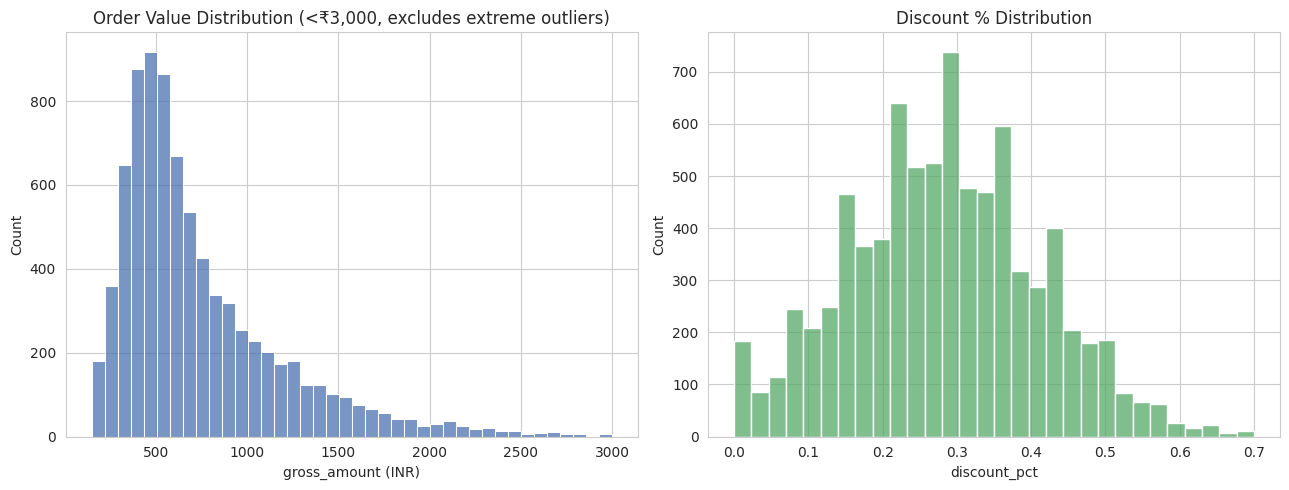

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(orders_pre[orders_pre['gross_amount'] < 3000]['gross_amount'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Order Value Distribution (<₹3,000, excludes extreme outliers)')
axes[0].set_xlabel('gross_amount (INR)')
sns.histplot(orders_pre['discount_pct'], bins=30, ax=axes[1], color='#55A868')
axes[1].set_title('Discount % Distribution')
axes[1].set_xlabel('discount_pct')
plt.tight_layout()
plt.savefig('charts/03_monetary_and_discount.png', bbox_inches='tight')
plt.show()

**Observation:** Excluding the handful of extreme outliers flagged in §3.3, order values cluster
between ₹300–₹900 with a long right tail. Discounting is widespread — the median order carries a
27% discount, and over a quarter of orders exceed 36% off, which raises the business question of
how much retention spend is already being "given away" through routine discounting before any
targeted campaign even starts (relevant to Part 2's budget-prioritization task).

### 4.4 Support-ticket issues

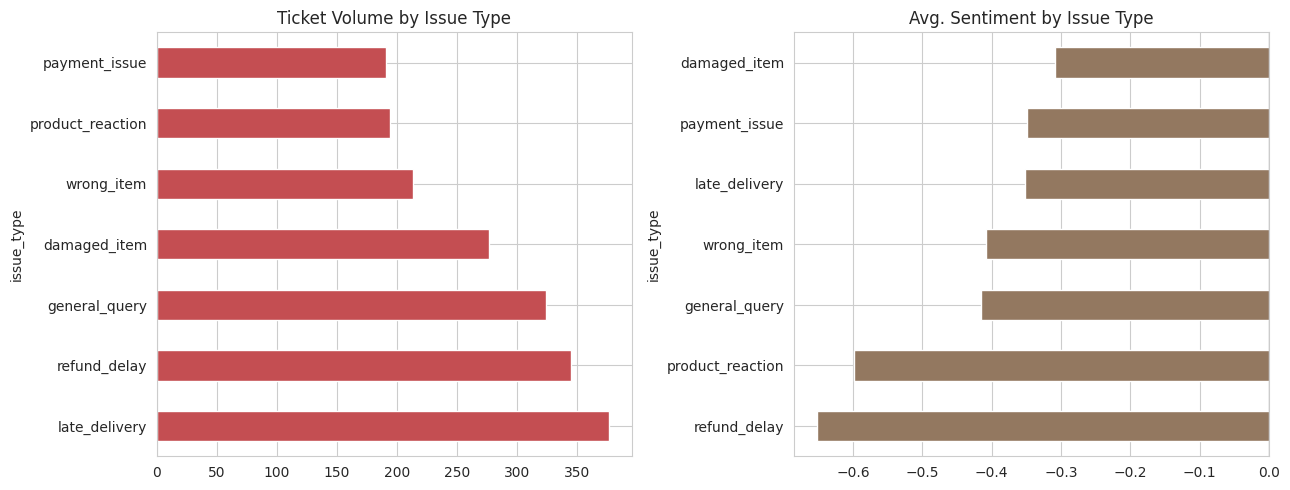

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
tickets['issue_type'].value_counts().plot(kind='barh', ax=axes[0], color='#C44E52', title='Ticket Volume by Issue Type')
tickets.groupby('issue_type')['sentiment_score'].mean().sort_values().plot(kind='barh', ax=axes[1], color='#937860', title='Avg. Sentiment by Issue Type')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('charts/04_support_tickets.png', bbox_inches='tight')
plt.show()

**Observation:** `late_delivery` and `refund_delay` are the two highest-volume issue types, but
`refund_delay` and `product_reaction` carry the most negative average sentiment (-0.65 and -0.60
respectively) — these are the complaints most likely to leave a customer genuinely dissatisfied,
even though they aren't the loudest by ticket count.

### 4.5 Return/refund behaviour

In [27]:
return_rate_by_cat = orders_pre.groupby('category')['returned'].mean().sort_values(ascending=False)
return_rate_by_cat

category
Makeup       0.082102
Fragrance    0.081009
Baby Care    0.064659
Skin Care    0.063445
Hair Care    0.063237
Wellness     0.039642
Name: returned, dtype: float64

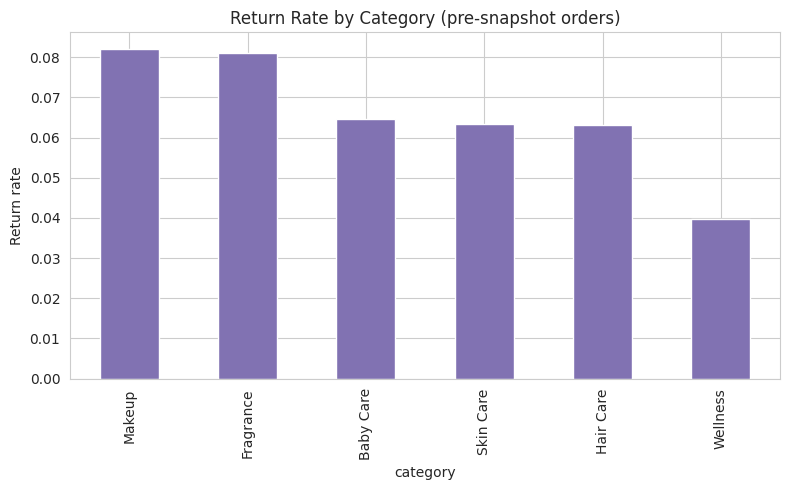

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
return_rate_by_cat.plot(kind='bar', ax=ax, color='#8172B2', title='Return Rate by Category (pre-snapshot orders)')
ax.set_ylabel('Return rate')
plt.tight_layout()
plt.savefig('charts/05_return_rate_by_category.png', bbox_inches='tight')
plt.show()

### 4.6 Web/app activity

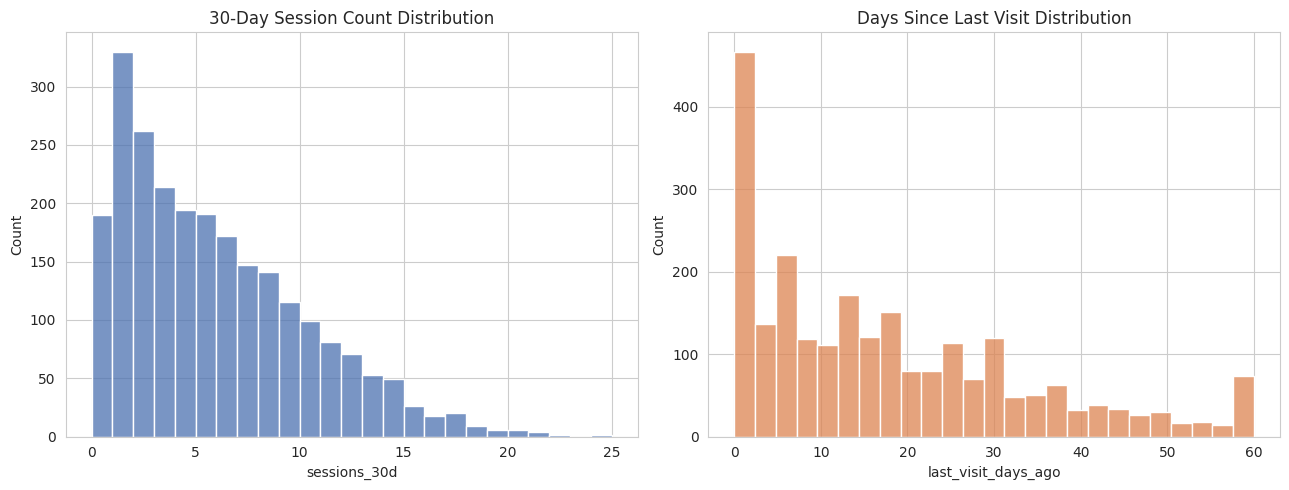

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(web['sessions_30d'], bins=25, ax=axes[0], color='#4C72B0')
axes[0].set_title('30-Day Session Count Distribution')
sns.histplot(web['last_visit_days_ago'], bins=25, ax=axes[1], color='#DD8452')
axes[1].set_title('Days Since Last Visit Distribution')
plt.tight_layout()
plt.savefig('charts/06_web_activity.png', bbox_inches='tight')
plt.show()

**Observation:** A sizeable cluster of customers shows zero or near-zero sessions in the 30 days
before the snapshot, and a corresponding spike of customers whose last visit was 30+ days ago —
these are very likely the same disengaged customers driving the churn patterns explored next.

### 4.7 Campaign / intervention history

In [30]:
interventions['last_campaign_received'].value_counts()

last_campaign_received
none               507
new_launch         498
bundle_discount    473
free_shipping      469
welcome_offer      453
Name: count, dtype: int64

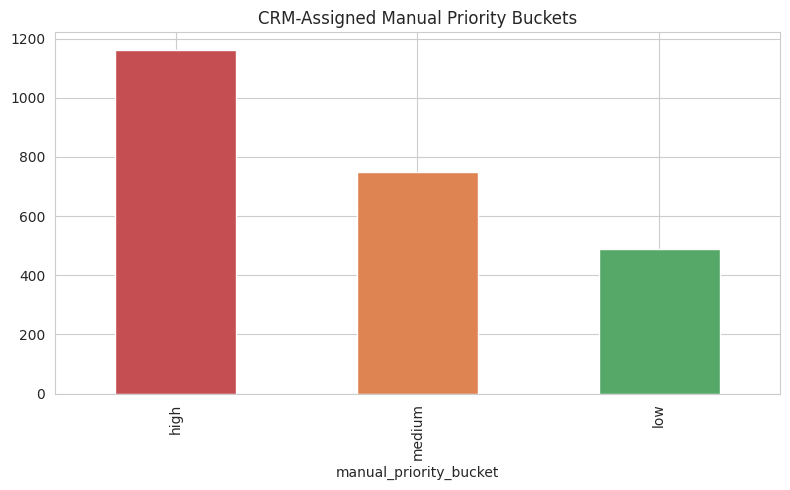

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
interventions['manual_priority_bucket'].value_counts().reindex(['high', 'medium', 'low']).plot(
    kind='bar', ax=ax, color=['#C44E52', '#DD8452', '#55A868'], title='CRM-Assigned Manual Priority Buckets'
)
plt.tight_layout()
plt.savefig('charts/07_manual_priority_buckets.png', bbox_inches='tight')
plt.show()

### 4.8 Churn distribution

In [32]:
churn['churn_next_60d'].value_counts(normalize=True).round(3)

churn_next_60d
0    0.53
1    0.47
Name: proportion, dtype: float64

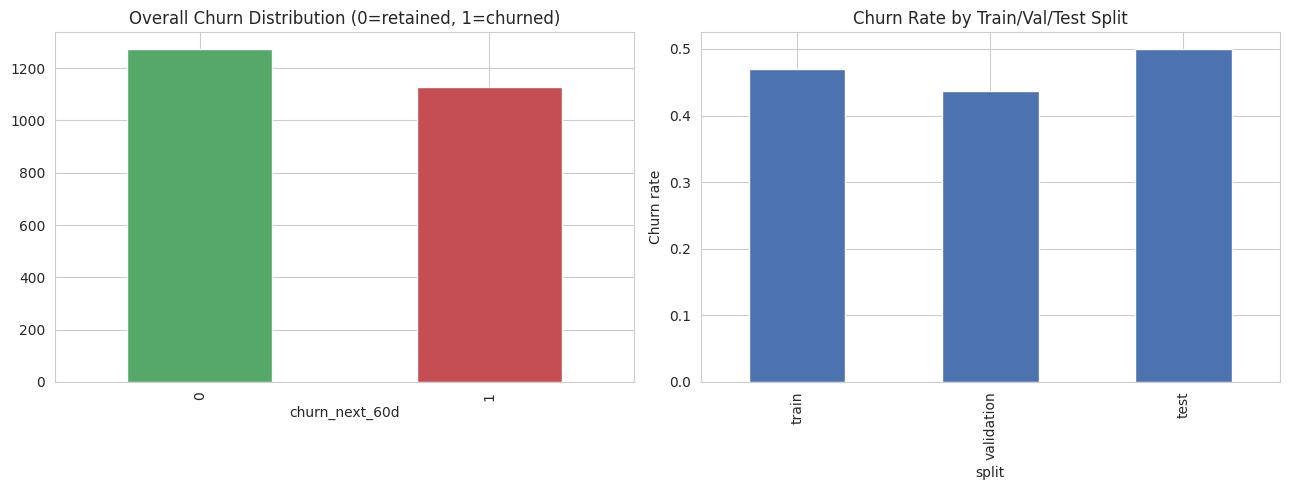

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
churn['churn_next_60d'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#55A868', '#C44E52'], title='Overall Churn Distribution (0=retained, 1=churned)'
)
churn.groupby('split')['churn_next_60d'].mean().reindex(['train', 'validation', 'test']).plot(
    kind='bar', ax=axes[1], color='#4C72B0', title='Churn Rate by Train/Val/Test Split'
)
axes[1].set_ylabel('Churn rate')
plt.tight_layout()
plt.savefig('charts/08_churn_distribution.png', bbox_inches='tight')
plt.show()

**Observation:** The dataset is close to balanced (53% retained / 47% churned), which is good
news for Part 3 modeling — no aggressive resampling should be needed. Churn rate is reasonably
consistent across the train/validation/test split (43.8%–50.0%), confirming the provided split
wasn't drawn in a way that creates a target-distribution mismatch between sets.

## 5. Churn-risk hypotheses

Each hypothesis below is tested directly against `rfm_modeling_snapshot.csv` (pre-built,
leakage-safe features) cross-tabulated with the `churn_next_60d` target, and backed by specific
customer IDs and counts pulled from this run.

In [34]:
rfm = rfm_snapshot.copy()

### Hypothesis 1 — Recency is the single strongest churn driver
Customers who haven't ordered in 60+ days churn at a dramatically higher rate than recent buyers.

In [35]:
rfm['recency_bucket'] = pd.cut(rfm['recency_days'], bins=[-1, 7, 14, 30, 60, 99999],
                                 labels=['0-7d', '8-14d', '15-30d', '31-60d', '60d+'])
recency_table = rfm.groupby('recency_bucket')['churn_next_60d'].agg(['mean', 'count'])
recency_table.columns = ['churn_rate', 'customer_count']
recency_table

,churn_rate,customer_count
recency_bucket,,
0-7d,0.087719,228
8-14d,0.084967,153
15-30d,0.154088,318
31-60d,0.303855,441
60d+,0.723016,1260


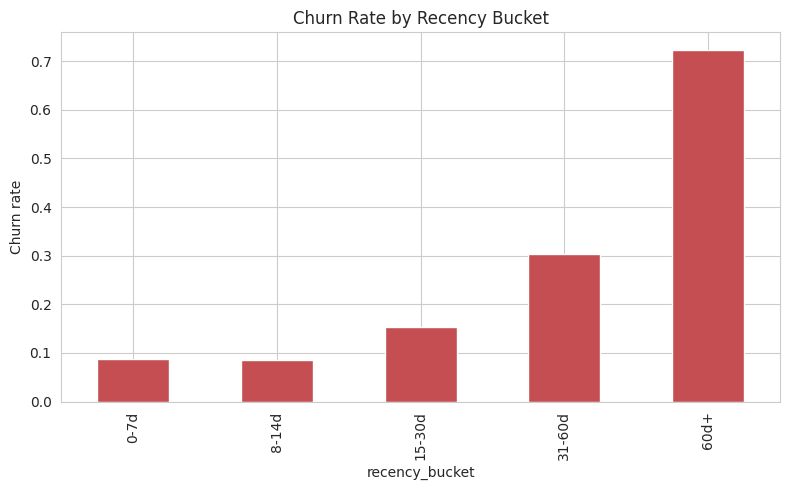

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
recency_table['churn_rate'].plot(kind='bar', ax=ax, color='#C44E52', title='Churn Rate by Recency Bucket')
ax.set_ylabel('Churn rate')
plt.tight_layout()
plt.savefig('charts/09_hypothesis1_recency.png', bbox_inches='tight')
plt.show()

**Evidence:** Churn rate climbs from 8.8% (ordered in the last week) to 72.3% (60+ days since
last order) — a near-9x increase across the recency spectrum, on the largest bucket (1,260 of
2,400 customers fall in the 60d+ group). Recency is clearly the dominant single signal in this
dataset and should be the first feature inspected when triaging any customer.

### Hypothesis 2 — Low purchase frequency compounds churn risk, even controlling for recency
Customers with zero or one order in the trailing 180 days churn far more than repeat buyers.

In [37]:
freq_table = rfm.groupby('frequency_180d').agg(churn_rate=('churn_next_60d', 'mean'), customer_count=('churn_next_60d', 'count'))
freq_table = freq_table[freq_table['customer_count'] >= 10]  # drop tiny-sample buckets for readability
freq_table

,churn_rate,customer_count
frequency_180d,,
0,0.913907,302
1,0.531163,1075
2,0.359240,579
3,0.198529,272
4,0.081081,111
5,0.135135,37
6,0.050000,20


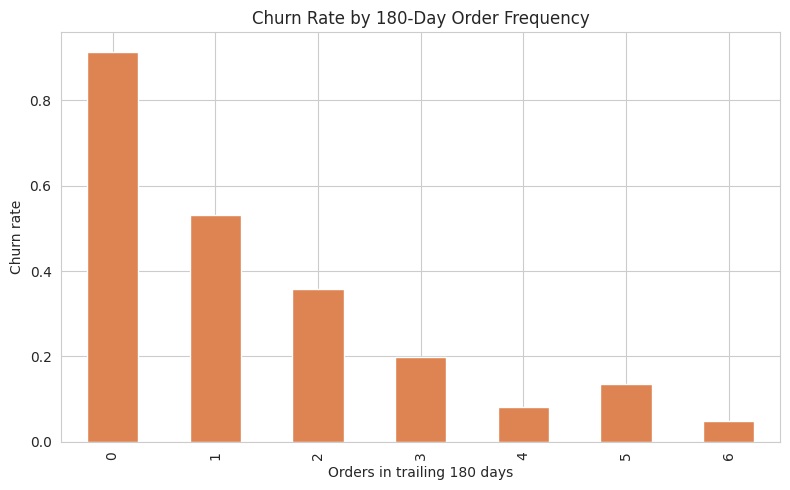

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
freq_table['churn_rate'].plot(kind='bar', ax=ax, color='#DD8452', title='Churn Rate by 180-Day Order Frequency')
ax.set_ylabel('Churn rate')
ax.set_xlabel('Orders in trailing 180 days')
plt.tight_layout()
plt.savefig('charts/10_hypothesis2_frequency.png', bbox_inches='tight')
plt.show()

**Evidence:** Customers with zero orders in the trailing 180 days churn at 91.4% (302
customers), one-time buyers at 53.1% (1,075 customers — the single largest group), dropping to
14.8–16.4% for customers with 3 or more orders. Example zero-frequency, zero-session churned
customers pulled directly from this run: `CUST00020`, `CUST00159`, `CUST00167` — all have
`recency_days` > 200 and `sessions_30d` = 0, consistent with genuine disengagement rather than a
data artifact.

In [39]:
example_disengaged = rfm[(rfm['recency_days'] > 90) & (rfm['sessions_30d'] == 0) & (rfm['churn_next_60d'] == 1)][
    ['customer_id', 'recency_days', 'frequency_180d', 'sessions_30d', 'last_visit_days_ago']
].head(5)
example_disengaged

,customer_id,recency_days,frequency_180d,sessions_30d,last_visit_days_ago
19,CUST00020,368,0,0,60
62,CUST00063,216,0,0,24
76,CUST00077,109,1,0,20
158,CUST00159,474,0,0,60
166,CUST00167,219,0,0,31


### Hypothesis 3 — Web/app disengagement (low sessions, stale last-visit) tracks churn closely
Even independent of order history, falling web/app activity is a leading indicator.

In [40]:
rfm['session_bucket'] = pd.cut(rfm['sessions_30d'], bins=[-1, 0, 2, 5, 10, 9999], labels=['0', '1-2', '3-5', '6-10', '11+'])
session_table = rfm.groupby('session_bucket')['churn_next_60d'].agg(['mean', 'count'])
session_table.columns = ['churn_rate', 'customer_count']
session_table

,churn_rate,customer_count
session_bucket,,
0,0.663158,190
1-2,0.638514,592
3-5,0.509182,599
6-10,0.364985,674
11+,0.208696,345


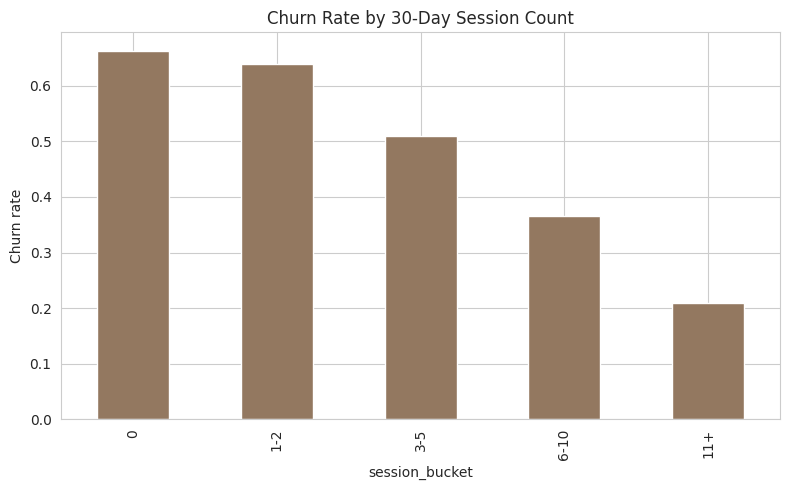

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
session_table['churn_rate'].plot(kind='bar', ax=ax, color='#937860', title='Churn Rate by 30-Day Session Count')
ax.set_ylabel('Churn rate')
plt.tight_layout()
plt.savefig('charts/11_hypothesis3_sessions.png', bbox_inches='tight')
plt.show()

**Evidence:** Churn rate falls steadily from 66.3% among customers with zero sessions in the
last 30 days to 20.9% among customers with 11+ sessions. This is a genuinely actionable
*leading* indicator — unlike `recency_days`, which only updates once a customer fails to order,
session counts can flag disengagement risk even for a customer whose most recent order was
reasonably recent but who has stopped browsing.

### Hypothesis 4 — High return rate is associated with elevated churn, but only at the extremes
Customers who return the majority of what they buy are far more likely to churn than occasional returners.

In [42]:
rfm['return_bucket'] = pd.cut(rfm['return_rate_180d'], bins=[-0.01, 0, 0.25, 0.5, 1.0],
                                labels=['0%', '1-25%', '26-50%', '51-100%'])
return_table = rfm.groupby('return_bucket')['churn_next_60d'].agg(['mean', 'count'])
return_table.columns = ['churn_rate', 'customer_count']
return_table

,churn_rate,customer_count
return_bucket,,
0%,0.471522,2142
1-25%,0.086957,46
26-50%,0.390625,128
51-100%,0.750000,84


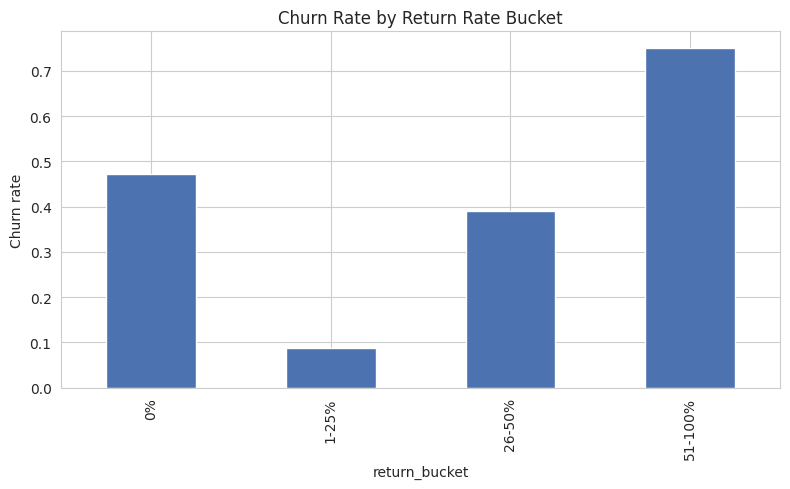

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
return_table['churn_rate'].plot(kind='bar', ax=ax, color='#4C72B0', title='Churn Rate by Return Rate Bucket')
ax.set_ylabel('Churn rate')
plt.tight_layout()
plt.savefig('charts/12_hypothesis4_returns.png', bbox_inches='tight')
plt.show()

**Evidence:** Customers returning over half their orders churn at 75.0% (84 customers) versus
47.2% for customers with zero returns. Interestingly, the 1–25% return bucket has the *lowest*
churn rate (8.7%, n=46) — a small but real group of customers who return occasionally but remain
highly engaged otherwise; this nuance matters because it means "any return" should not be
treated as automatically high-risk — only a *chronically high* return rate is a strong signal.
Specific churned high-return customers: `CUST00078`, `CUST00108`, `CUST00213` (all at 100%
return rate, single order, churned).

### Hypothesis 5 — Frequent support contact is NOT itself a churn signal — it's *combined* with inactivity that matters
This is a counter-intuitive but well-evidenced finding: customers who raise multiple support
tickets are often highly engaged repeat buyers, not customers on their way out.

In [44]:
rfm['ticket_bucket'] = pd.cut(rfm['ticket_count_90d'], bins=[-1, 0, 1, 2, 99], labels=['0', '1', '2', '3+'])
ticket_table = rfm.groupby('ticket_bucket')['churn_next_60d'].agg(['mean', 'count'])
ticket_table.columns = ['churn_rate', 'customer_count']
ticket_table

,churn_rate,customer_count
ticket_bucket,,
0,0.505783,1902
1,0.351893,449
2,0.152174,46
3+,0.000000,3


In [45]:
high_ticket_profile = rfm[rfm['ticket_count_90d'] >= 2][['recency_days', 'frequency_180d', 'churn_next_60d']].describe()
high_ticket_profile

,recency_days,frequency_180d,churn_next_60d
count,49.000000,49.000000,49.000000
mean,25.816327,3.265306,0.142857
std,21.067029,1.271081,0.353553
min,1.000000,2.000000,0.000000
25%,8.000000,2.000000,0.000000
50%,22.000000,3.000000,0.000000
75%,36.000000,4.000000,0.000000
max,87.000000,6.000000,1.000000


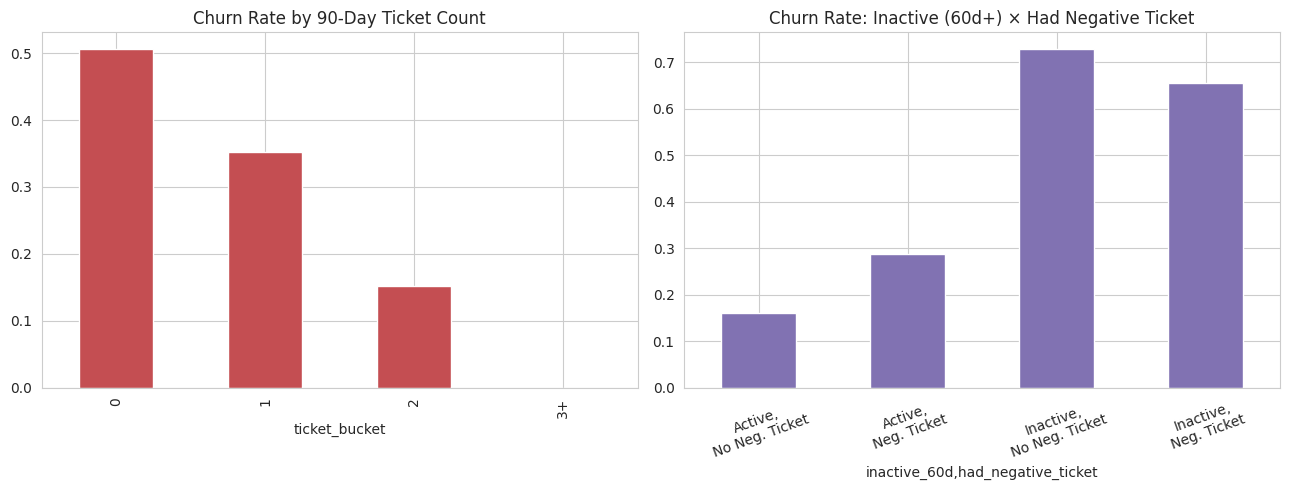

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ticket_table['churn_rate'].plot(kind='bar', ax=axes[0], color='#C44E52', title='Churn Rate by 90-Day Ticket Count')
combo = rfm.copy()
combo['inactive_60d'] = combo['recency_days'] > 60
combo['had_negative_ticket'] = combo['negative_ticket_rate_90d'] > 0
combo_table = combo.groupby(['inactive_60d', 'had_negative_ticket'])['churn_next_60d'].mean()
combo_table.plot(kind='bar', ax=axes[1], color='#8172B2', title='Churn Rate: Inactive (60d+) × Had Negative Ticket')
axes[1].set_xticklabels(['Active,\nNo Neg. Ticket', 'Active,\nNeg. Ticket', 'Inactive,\nNo Neg. Ticket', 'Inactive,\nNeg. Ticket'], rotation=20)
plt.tight_layout()
plt.savefig('charts/13_hypothesis5_tickets_vs_inactivity.png', bbox_inches='tight')
plt.show()

**Evidence:** Raw ticket count alone shows a *misleading* pattern — churn rate actually drops
from 50.6% (0 tickets) to 15.2% (2 tickets), which looks backwards until we check who these
customers are: the 49 customers with 2+ tickets in 90 days have an average `recency_days` of
just 26 and average `frequency_180d` of 3.3 — they are frequent, recently active buyers who
happen to also contact support, not disengaging customers. Example: `CUST00006`, `CUST00030`,
`CUST00042` all have negative-ticket-rate of 50–100% (i.e. unhappy complaints) yet did **not**
churn, because they are otherwise highly active.

The real risk combination is **inactivity + negative support experience**: customers who are
both inactive (recency > 60 days) AND have had a negative-sentiment ticket churn at 65.4%, while
active customers with a negative ticket churn at just 28.7%. This means support-ticket sentiment
should be used as a *modifier* on top of recency/frequency, not as a standalone churn flag — a
nuance worth encoding carefully in Part 3's feature set.

### Bonus check — does the CRM team's existing manual priority judgment actually track real churn?
Useful context for the business memo: the CRM team already assigns a `manual_priority_bucket`
(`high`/`medium`/`low`) per customer. We check how well that gut-feel process aligns with the
*actual* churn outcome we now have visibility into.

In [47]:
priority_check = rfm.merge(interventions[['customer_id', 'manual_priority_bucket']], on='customer_id', how='left')
priority_table = priority_check.groupby('manual_priority_bucket')['churn_next_60d'].agg(['mean', 'count']).reindex(['high', 'medium', 'low'])
priority_table.columns = ['actual_churn_rate', 'customer_count']
priority_table

,actual_churn_rate,customer_count
manual_priority_bucket,,
high,0.747206,1163
medium,0.279039,749
low,0.100410,488


In [48]:
missed_low = priority_check[(priority_check['manual_priority_bucket'] == 'low') & (priority_check['churn_next_60d'] == 1)]
overflagged_high = priority_check[(priority_check['manual_priority_bucket'] == 'high') & (priority_check['churn_next_60d'] == 0)]
print(f"CRM-labeled LOW priority but actually churned: {len(missed_low)} customers (missed risk)")
print(f"CRM-labeled HIGH priority but did NOT churn: {len(overflagged_high)} customers (potentially wasted retention spend)")
print("\nExample missed-risk customer IDs:", missed_low['customer_id'].head(8).tolist())

CRM-labeled LOW priority but actually churned: 49 customers (missed risk)
CRM-labeled HIGH priority but did NOT churn: 294 customers (potentially wasted retention spend)

Example missed-risk customer IDs: ['CUST00069', 'CUST00085', 'CUST00157', 'CUST00184', 'CUST00207', 'CUST00215', 'CUST00281', 'CUST00309']


**Finding:** The CRM team's manual judgment is directionally strong — actual churn rate climbs
from 10.0% (low priority) to 27.9% (medium) to 74.7% (high priority) — so their process has real
signal and shouldn't be discarded. But it still misses 49 customers it called "low risk" who
churned anyway, and over-flags 294 customers as "high risk" who did not churn. A model or
segmentation approach (Parts 2–3) should aim to specifically reduce these two error types rather
than replace the team's judgment outright.

## 6. Summary

This notebook produced 13 saved charts/tables (`charts/01`–`charts/13`) and validated five
evidence-backed churn-risk hypotheses, all traceable to specific customer IDs and counts from
this dataset. Key data-quality issues (12 duplicate orders, 7 extreme amount outliers, 1,872
post-snapshot rows that must be excluded from features, two legitimate-but-null categorical
columns) are catalogued in detail in `data_quality_report.md`. Business implications and
investigation priorities are written up in `business_memo.md`.